# (Try to) identify signals of gentrification from Airbnb data

In [102]:
import os
import re
import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from scipy.stats import zscore, gaussian_kde
import matplotlib.patches as mpatches
import matplotlib.colors as colors
from datetime import datetime
import seaborn as sns
from shapely.geometry import Point
from geopandas import GeoDataFrame
from IPython.core.pylabtools import figsize
from fontTools.varLib.interpolatableHelpers import matching_for_vectors
import folium
import branca.colormap as cm
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from PlottingFunctions import *

cmap = plt.get_cmap('plasma', 5)  # 5 discrete colors
plot_colors = [cmap(i) for i in range(5)]
plot_colors[4] = 'gold'

city='manchester'

### Get just Manchester LSOAs

In [103]:
lsoas =  gpd.read_file('../../data/LSOAs_2011/LSOA_2011_EW_BSC_V4.shp')
manc_lads = ['Manchester', 'Rochdale', 'Bolton', 'Bury', 'Wigan', 'Oldham',  'Trafford', 'Salford', 'Tameside', 'Stockport']
manc_lads_pattern = '|'.join(manc_lads)
manchester_lsoas=lsoas[lsoas['LSOA11NMW'].str.contains(manc_lads_pattern)]

### Read in socioeconomic indicator data

In [104]:
indicators = pd.read_csv("../../data/SocioEconomicData/Eng_imputedV3.csv") # for the whole o England
# Get just for Manchester
indicators_manchester = indicators[indicators['LA_NAME'].str.contains(manc_lads_pattern)].copy()
indicators_manchester = indicators_manchester.rename(columns={"LSOA": 'LSOA11CD'})
del indicators_manchester['Churn_2020']
indicators_manchester.reset_index(inplace=True, drop=True)
len(indicators_manchester)

1673

## Get gentrification scores, convert string to categorical

In [105]:
base_dir = os.path.expanduser(f"../../data/airbnb-{city}/")
gentrication_cat_df = pd.read_csv(base_dir + 'airbnb_gentrification_scores_categorical_combined_listings_filtered_01.csv')
mapping = {'Na': 0,'Undeveloped': 1, 'Emerging': 2, 'Gentrifying': 3, 'Established': 4}
gentrication_cat_df['gentrification_prediction_code'] = gentrication_cat_df['gentrification_prediction'].map(mapping)

### Convert to a geodataframe

In [106]:
gentrication_cat_df['geometry'] = gentrication_cat_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gentrication_cat_gdf = gpd.GeoDataFrame(gentrication_cat_df, geometry='geometry', crs="EPSG:4326")
gentrication_cat_gdf = gentrication_cat_gdf[['LSOA11NM', 'gentrification_prediction_code']]
gentrication_cat_gdf = gentrication_cat_gdf.merge(manchester_lsoas[['LSOA11NM', 'LSOA11CD']], on='LSOA11NM', how='left')

### Find the most common score in each LSOA

In [107]:
lsoa_scores = pd.DataFrame({'score': gentrication_cat_gdf.groupby("LSOA11CD")["gentrification_prediction_code"].agg(lambda x: pd.Series.mode(x).iloc[0]), 
              'count':gentrication_cat_gdf.groupby("LSOA11CD")["gentrification_prediction_code"].count()})
lsoa_scores.reset_index(inplace=True)

### Join the LSOA scores to the socio-economic indicators

In [108]:
indicators_manchester = indicators_manchester.merge(lsoa_scores, on='LSOA11CD', how='right')
indicators_manchester.sort_values(by='score', inplace=True)

### Join the gentrification index data

In [109]:
g_index = pd.read_csv("../../data/ManchesterIndex/manc_index.csv") 
# g_index_cols_to_join = ['LSOA11CD', 'gi_n', 'rmd_z', 'house_price_z', 'BME_z', 'churn_z', 'wage_change_z',
#     'rmd', 'hp_pc_change', 'poc_ppt', 'chn2013', 'wage_change']

g_index_cols_to_join = ['LSOA11CD', 'rmd', 'hp_pc_change', 'poc_ppt', 'chn2013', 'wage_change', 'gi_n' ]

# Merge the specified columns into indicators_manchester
indicators_manchester = indicators_manchester.merge( g_index[g_index_cols_to_join],on='LSOA11CD', how='left')

# remove LSOA from the list (for later use)
del g_index_cols_to_join[0]

### Scale the indicators

In [112]:
numeric_cols = indicators_manchester.columns
numeric_cols = numeric_cols.drop(['LSOA11CD', 'LA_NAME', 'score', 'count', 'gi_n'])

standard_scaler = StandardScaler()
scaled_standard = standard_scaler.fit_transform(indicators_manchester[numeric_cols])

# Convert scaled values back to DataFrame and concatenate with original non-numeric columns
scaled_standard_df = pd.DataFrame(scaled_standard, columns=numeric_cols)
indicators_manchester_standard = pd.concat([indicators_manchester[['LSOA11CD', 'LA_NAME', 'score', 'count', 'gi_n']], scaled_standard_df], axis=1)

## Rose plots

In [94]:
# Precompute global max
# global_max = 0
# for gentr_class in indicators_manchester_standard['gentrification_prediction_code'].unique():
#     class_data = indicators_manchester_standard[
#         indicators_manchester_standard['gentrification_prediction_code'] == gentr_class]
#     max_val = class_data[numeric_cols].mean().max() + class_data[numeric_cols].std().max()
#     global_max = max(global_max, max_val)
# global_max *= 1.1
# global_max= 2

In [95]:
def plot_simple_radar_GI(ax, indicators, all_vars, labels=None, color='blue', title='Radar Chart',
                         show_std=False, label_size=10, fixed_max=None, show_radial_labels=True):
    # Labels fallback
    if labels is None:
        labels = {var: var for var in all_vars}  # Use variable names if no labels provided

    # Calculate stats
    means = indicators[all_vars].mean().values.tolist()
    means += means[:1]
    angles = np.linspace(0, 2 * np.pi, len(all_vars), endpoint=False).tolist()
    angles += angles[:1]

    if show_std:
        stds = indicators[all_vars].std().values.tolist()
        stds += stds[:1]
        std_upper = np.array(means) + np.array(stds)
        std_lower = np.array(means) - np.array(stds)
        max_val = max(std_upper) * 1.1
    else:
        std_upper = std_lower = None
        max_val = max(means) * 1.1

    if fixed_max is not None:
        max_val = fixed_max

    # Set scale
    data_min = min(means if not show_std else std_lower)
    data_max = max(means if not show_std else std_upper)
    buffer = (data_max - data_min) * 0.1

    if fixed_max is not None:
        ax.set_ylim(-fixed_max, fixed_max)
    # ax.set_ylim(data_min - buffer, max_val)

    # Ticks
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    if show_radial_labels:
        ticks = np.linspace(ax.get_ylim()[0], max_val, 5)
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{tick:.1f}" for tick in ticks], fontsize=9)
    else:
        ax.set_yticklabels([])

    # Main plot
    ax.plot(angles, means, color=color, linewidth=4)
    ax.scatter(angles, means, color=color, s=30)

    # Std shading
    if show_std and std_upper is not None:
        for i in range(10):
            alpha = 0.1
            lower = std_lower + (np.array(means) - std_lower) * (i / 10)
            upper = std_upper - (std_upper - np.array(means)) * (i / 10)
            ax.fill_between(angles, lower, upper, color=color, alpha=alpha)

    # Title
    ax.set_title(title, size=13, pad=30)

    # Simple labels (no groups)
    for i, var in enumerate(all_vars):
        angle = angles[i]
        label = labels.get(var, var)
    
        # Set a radius to push label out slightly
        radius = max_val * 0.9
    
        # Convert angle to degrees
        angle_deg = np.rad2deg(angle)
    
        # Set rotation mode
        if angle_deg >= 90 and angle_deg <= 270:
            rotation = angle_deg + 180  # Flip upside down
            alignment = 'right'
        else:
            rotation = angle_deg
            alignment = 'left'
    
        ax.text(angle, radius, label,
                ha=alignment, va='center',
                fontsize=label_size,
                fontweight='bold',
                rotation=0,
                rotation_mode='anchor')

        


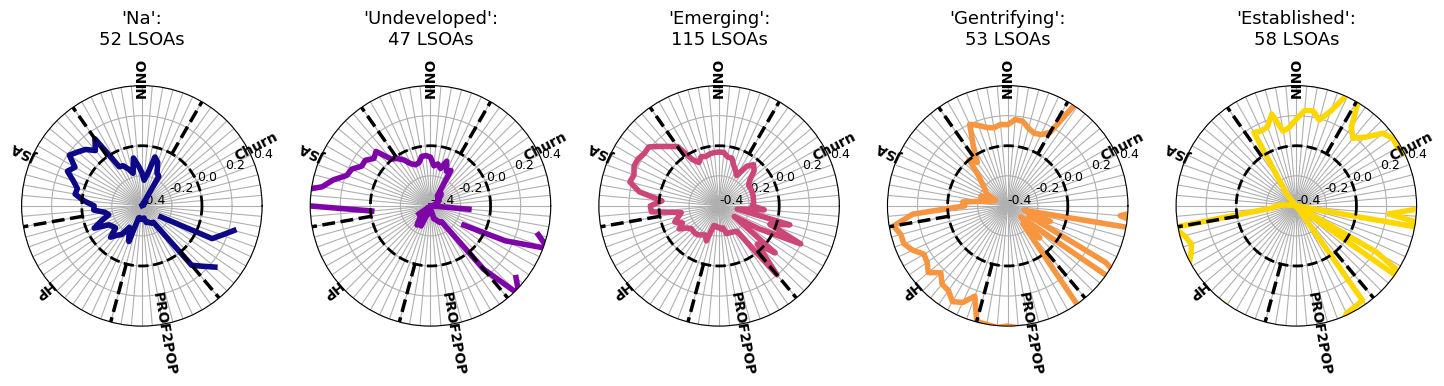

In [83]:
fig, axs = plt.subplots(subplot_kw={'projection': 'polar'}, ncols=5, nrows=1, figsize=(18, 8), sharex=True, sharey=True)

for gentr_class, ax in enumerate(axs.flatten()):
    class_data = indicators_manchester_standard[
        indicators_manchester_standard['score'] == gentr_class]
    if class_data.empty:
        ax.set_axis_off()
    else:
        key = [k for k, v in mapping.items() if v == gentr_class][0]
        plot_flexible_radar( ax, class_data, numeric_cols,
            color=plot_colors[gentr_class],  title=f"'{key}':\n{len(class_data)} LSOAs", show_std=False, fixed_max=0.4)
    ax.plot(np.linspace(0, 2 * np.pi, 100), np.zeros(100), color='black', linewidth=2, linestyle='dashed')

### plot for all (think its not the same as the circle, case we're not including all the LSOAs in manc)

In [4]:
# fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(9, 4))
# plot_simple_radar_GI(ax, indicators_manchester_standard, g_index_cols_to_join,
#     color='black',  title=f"'{key}':\n{len(class_data)} LSOAs", show_std=False, fixed_max=2)
# ax.plot(np.linspace(0, 2 * np.pi, 100), np.zeros(100), color='black', linewidth=2, linestyle='dashed')

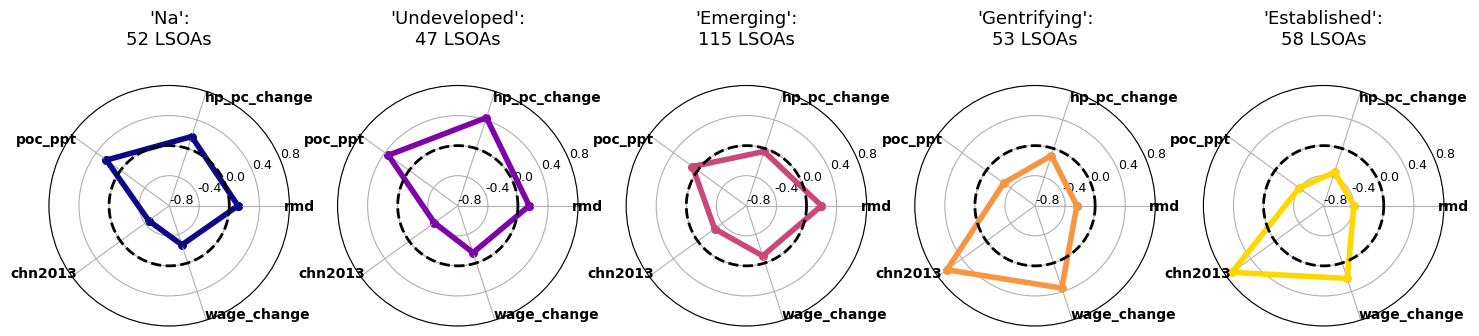

In [114]:
fig, axs = plt.subplots(subplot_kw={'projection': 'polar'}, ncols=5, nrows=1, figsize=(18, 8), sharex=True, sharey=True)

for gentr_class, ax in enumerate(axs.flatten()):
    class_data = indicators_manchester_standard[
        indicators_manchester_standard['score'] == gentr_class]
    if class_data.empty:
        ax.set_axis_off()
    else:
        key = [k for k, v in mapping.items() if v == gentr_class][0]
        plot_simple_radar_GI( ax, class_data, cols,
            color=plot_colors[gentr_class],  title=f"'{key}':\n{len(class_data)} LSOAs", show_std=False, fixed_max=0.8)
    ax.plot(np.linspace(0, 2 * np.pi, 100), np.zeros(100), color='black', linewidth=2, linestyle='dashed')

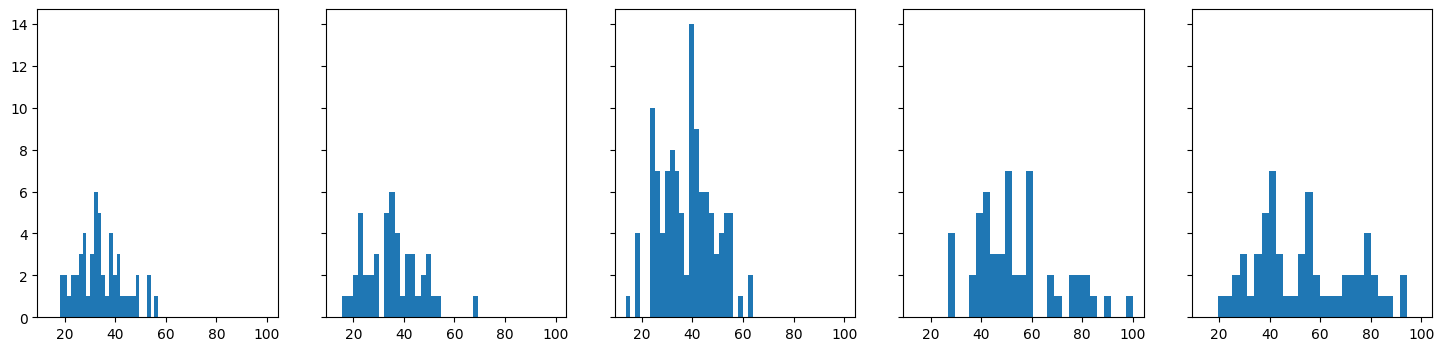

In [121]:
cols = ['rmd', 'hp_pc_change', 'poc_ppt', 'chn2013', 'wage_change']
fig, axs = plt.subplots( ncols=5, nrows=1, figsize=(18, 4), sharex=True, sharey=True)

for gentr_class, ax in enumerate(axs.flatten()):
    class_data = indicators_manchester_standard[
        indicators_manchester_standard['score'] == gentr_class]
    if class_data.empty:
        ax.set_axis_off()
    else:
        ax.hist(class_data['gi_n'], bins=26)

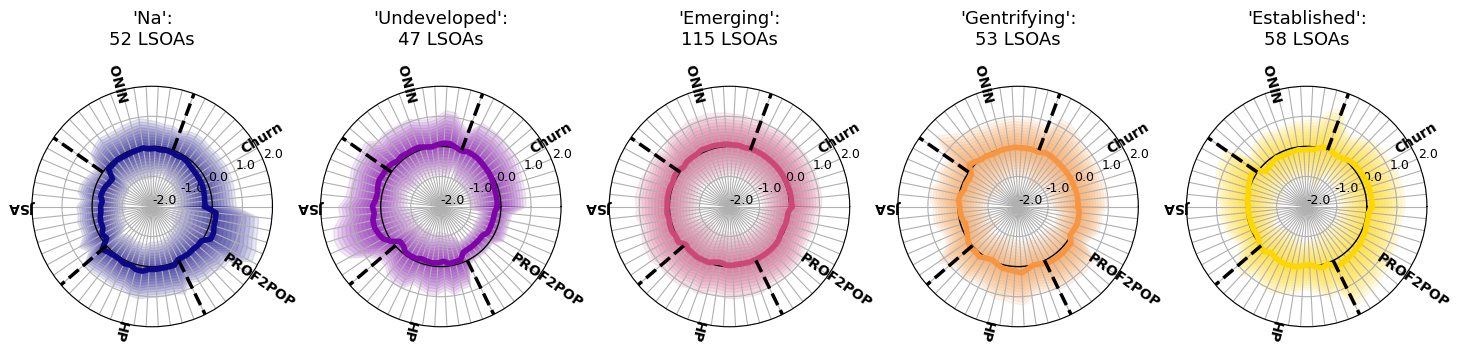

In [24]:
fig, axs = plt.subplots(subplot_kw={'projection': 'polar'}, ncols=5, nrows=1, figsize=(18, 8), sharex=True, sharey=True)

for gentr_class, ax in enumerate(axs.flatten()):
    ax.plot(np.linspace(0, 2 * np.pi, 100), np.zeros(100), color='black', linewidth=1)
    class_data = indicators_manchester_standard[
        indicators_manchester_standard['score'] == gentr_class]
    if class_data.empty:
        ax.set_axis_off()
    else:
        key = [k for k, v in mapping.items() if v == gentr_class][0]
        plot_flexible_radar( ax, class_data, numeric_cols,
            color=plot_colors[gentr_class],  title=f"'{key}':\n{len(class_data)} LSOAs", show_std=True, fixed_max=2)

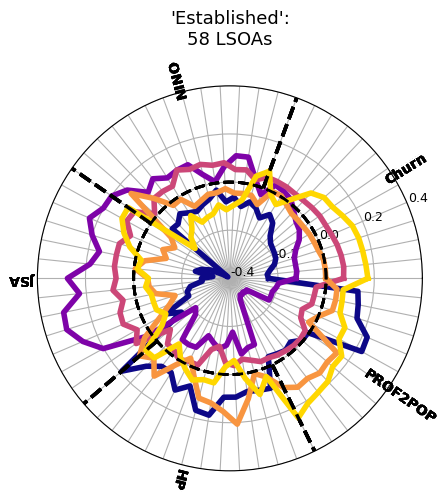

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': 'polar'}, sharey=True)
for gentr_class in indicators_manchester_standard['score'].unique():
    gentr_class=int(gentr_class)
    class_data = indicators_manchester_standard[indicators_manchester_standard['score'] == gentr_class]
    if class_data.empty:
        ax.set_axis_off()
    else:
        key = [k for k, v in mapping.items() if v == gentr_class][0]
        plot_flexible_radar(ax, class_data, numeric_cols,
            color=plot_colors[gentr_class],  title='All', show_std=False, fixed_max=0.4)
    ax.plot(np.linspace(0, 2 * np.pi, 100), np.zeros(100), color='black', linewidth=2, linestyle='dashed')

In [14]:
lsoa_scores = lsoa_scores.merge(manchester_lsoas, on='LSOA11CD', how='left')
lsoa_scores_gdf = gpd.GeoDataFrame(lsoa_scores, geometry='geometry', crs="EPSG:27700")

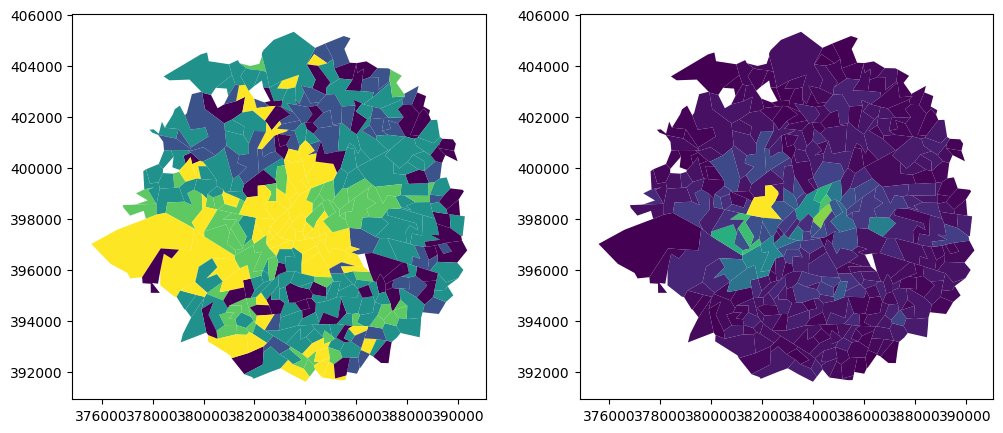

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1]})  # Ensure equal subplot sizes
lsoa_scores_gdf.plot(ax = axs[0],column =  "score")
lsoa_scores_gdf.plot(ax = axs[1],column = "count");

In [22]:
import folium
from folium import Choropleth, LayerControl, GeoJson
import geopandas as gpd

# Ensure GeoDataFrame is in WGS84 for Folium
lsoa_scores_gdf = lsoa_scores_gdf.to_crs(epsg=4326)

# Create base map
m = folium.Map(location=[lsoa_scores_gdf.geometry.centroid.y.mean(),
              lsoa_scores_gdf.geometry.centroid.x.mean()],zoom_start=11)

# --- Score Layer ---
score_map = Choropleth(
    geo_data=lsoa_scores_gdf,
    data=lsoa_scores_gdf,
    columns=['LSOA11CD', 'score'],
    key_on='feature.properties.LSOA11CD',
    fill_color='YlGnBu',
    fill_opacity=0.9,
    line_opacity=0.2,
    legend_name='Score'
)
score_map.add_to(m)

# Add boundaries and labels as a GeoJson layer for score
GeoJson(
    lsoa_scores_gdf,
    name='Score',
    tooltip=folium.GeoJsonTooltip(fields=['LSOA11CD', 'score'])
).add_to(m)

# Add layer control
LayerControl().add_to(m)

# Display map
m


/tmp/ipykernel_21327/1444027839.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  location=[lsoa_scores_gdf.geometry.centroid.y.mean(),
/tmp/ipykernel_21327/1444027839.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lsoa_scores_gdf.geometry.centroid.x.mean()],


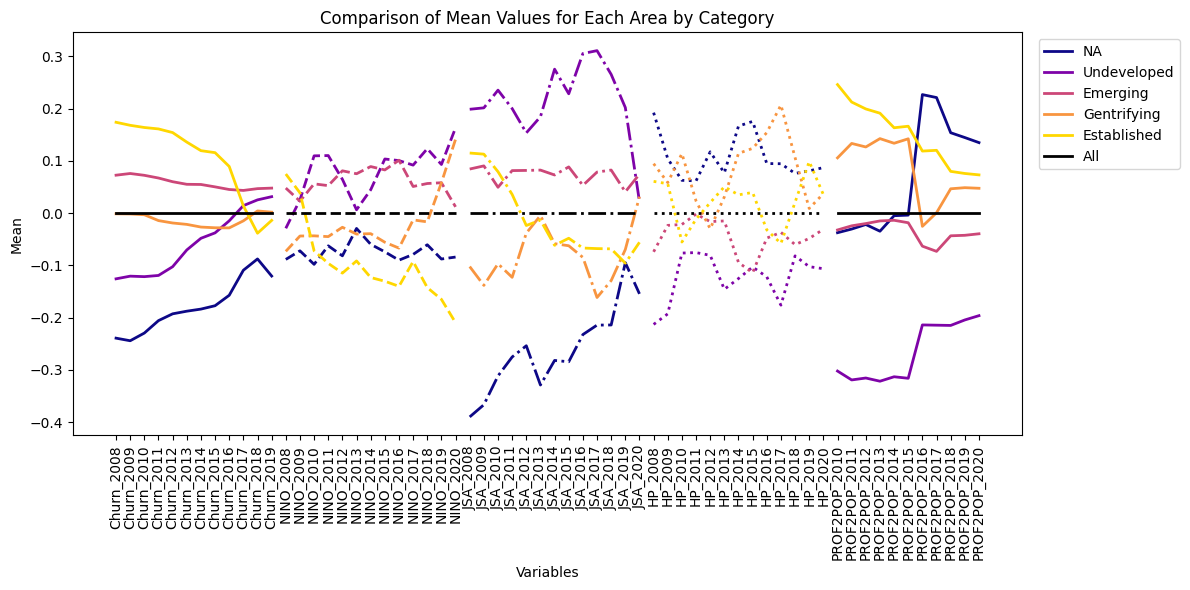

In [16]:
from matplotlib.lines import Line2D

# Define variable categories (based on column names or your own grouping logic)
variable_categories = {
    'Churn': [col for col in indicators_manchester_standard.columns if 'Churn' in col],
    'NINO': [col for col in indicators_manchester_standard.columns if 'NINO' in col],
    'JSA': [col for col in indicators_manchester_standard.columns if 'JSA' in col],
    'HP': [col for col in indicators_manchester_standard.columns if 'HP' in col],
    'PROF2POP': [col for col in indicators_manchester_standard.columns if 'PROF2POP' in col]
}

# Compute mean and std for all areas
areas = { "NA": indicators_manchester_standard[indicators_manchester_standard['score'] == 0],
    "Undeveloped": indicators_manchester_standard[indicators_manchester_standard['score'] == 1],
    "Emerging": indicators_manchester_standard[indicators_manchester_standard['score'] == 2],
    "Gentrifying": indicators_manchester_standard[indicators_manchester_standard['score'] == 3],
    "Established": indicators_manchester_standard[indicators_manchester_standard['score'] == 4],
    'All': indicators_manchester_standard}

# Compute mean and std for all areas
stats = {}
for area, df in areas.items():
    stats[area] = {
        "Mean": df.drop(columns=['LSOA11CD', 'LA_NAME', 'score']).mean(),
        "Std": df.drop(columns=['LSOA11CD', 'LA_NAME', 'score']).std(),
        'len': len(df)}

# Plot means for all areas, with grouping by categories
plt.figure(figsize=(12, 6))

# Different line styles for categories
category_styles = {'Churn': '-', 'NINO': '--', 'JSA': '-.', 'HP': ':', 'PROF2POP': '-'}

# Different colors for areas
area_colors = {"NA": plot_colors[0],"Undeveloped": plot_colors[1],"Emerging": plot_colors[2],"Gentrifying": plot_colors[3],"Established": plot_colors[4],'All': 'k' }

# Plot lines for each area with different categories
for area, stat in stats.items():
    # Plot each category separately
    for category, variables in variable_categories.items():
        # Extract mean values for this category
        category_mean = stat["Mean"][variables]
        
        # Plot with the corresponding color for the area and linestyle for the category
        plt.plot(category_mean, label=f'{area} - {category}', 
                 color=area_colors[area], linestyle=category_styles[category], linewidth=2)

# Rotate x-axis labels and adjust the layout
plt.xticks(rotation=90)
custom_legend = [Line2D([0], [0], color=area_colors[area], lw=2, label=area) for area in areas]

# Add the custom legend to the plot
plt.legend(handles=custom_legend, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.xlabel('Variables')
plt.ylabel('Mean')
plt.title('Comparison of Mean Values for Each Area by Category')

plt.tight_layout()
plt.show()
